# 03 — Données de marché, nettoyage et volatilité implicite

**Données.** Chaîne d'options SPY de fin de journée (16h00 ET) sur toute l'année 2022, source OptionsDX (`data/spy_2022.csv`, 1,15 M lignes, une ligne = un strike × une échéance × une date avec call et put). Date de référence de ce notebook : **1er août 2022** (première date du fichier, S ≈ 410,7 $).

**Question.** Peut-on extraire une volatilité implicite fiable des prix de marché, et quelle méthode numérique utiliser ?

On cherche $\sigma_{imp}$ tel que $BS(S, K, T, r, q, \sigma_{imp}) = P_{mid}$, où $P_{mid} = (bid + ask)/2$. Le **mid** est préféré au *last* : le dernier échange peut dater de plusieurs heures (prix périmé), alors que le mid reflète le marché au moment de l'extraction.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
import time
from scipy.optimize import brentq
from market_data import get_option_chain
from data_cleaning import clean_option_chain
from implied_vol import (implied_volatility, implied_volatility_newton, add_implied_volatility,
                         estimate_implied_dividend, add_implied_dividend)
from diagnostics import build_diagnostic_table
from black_scholes import black_scholes_price
from pipeline import load_chain_with_iv, otm_mask, R_DEFAULT, Q_DEFAULT

REF_DATE = "2022-08-01"
r = R_DEFAULT

## 1. Données brutes

In [2]:
raw = get_option_chain(quote_date=REF_DATE)
print(f"{len(raw):,} options ({(raw.option_type=='call').sum():,} calls / {(raw.option_type=='put').sum():,} puts)")
print(f"Spot SPY : {raw.spot.iloc[0]:.2f} $ | {raw.expiration.nunique()} échéances | {raw.strike.nunique()} strikes distincts")
print(f"Échéances : de {raw.expiration.min()} à {raw.expiration.max()}")
print("NB : C_SIZE / P_SIZE sont des tailles 'bid x ask', pas de l'open interest -> open_interest = 0 dans ce jeu de données.")
raw.head()

9,236 options (4,618 calls / 4,618 puts)
Spot SPY : 410.72 $ | 33 échéances | 316 strikes distincts
Échéances : de 2022-08-01 à 2024-12-20
NB : C_SIZE / P_SIZE sont des tailles 'bid x ask', pas de l'open interest -> open_interest = 0 dans ce jeu de données.


,underlying,quote_date,expiration,option_type,strike,bid,ask,last_price,volume,open_interest,source_iv,spot
0,SPY,2022-08-01,2022-08-01,call,260.0000,148.9800,151.5600,0.0000,0.0000,0.0000,NaN,410.7200
1,SPY,2022-08-01,2022-08-01,call,265.0000,144.0900,146.5400,0.0000,0.0000,0.0000,NaN,410.7200
2,SPY,2022-08-01,2022-08-01,call,270.0000,139.0900,141.5100,0.0000,0.0000,0.0000,NaN,410.7200
3,SPY,2022-08-01,2022-08-01,call,275.0000,134.0900,136.5400,0.0000,0.0000,0.0000,NaN,410.7200
4,SPY,2022-08-01,2022-08-01,call,280.0000,129.0900,131.5600,0.0000,0.0000,0.0000,NaN,410.7200


## 2. Nettoyage des données

Filtres appliqués par `clean_option_chain` : doublons, bid ≥ 0, ask > 0, ask ≥ bid, mid > 0, strike > 0, maturité > 0 (on exclut les 0DTE), et spread relatif $(ask-bid)/mid \le 50\,\%$. La vérification des bornes d'arbitrage est faite ensuite, lors de l'inversion de l'IV.

In [3]:
cleaned, control = clean_option_chain(raw, max_relative_spread=0.5)
control["Supprimées"] = -control["Nombre de lignes"].diff().fillna(0).astype(int)
control["% restant"] = 100 * control["Nombre de lignes"] / control["Nombre de lignes"].iloc[0]
save_table(control, "03_cleaning_control_table", floatfmt=".1f")
control

,Étape,Nombre de lignes,Supprimées,% restant
0,Données brutes,9236,0,100.0000
1,Après suppression des doublons,9236,0,100.0000
2,Après vérification bid/ask,9229,7,99.9242
3,Après filtre de maturité,8929,300,96.6761
4,Après filtre de spread,8427,502,91.2408


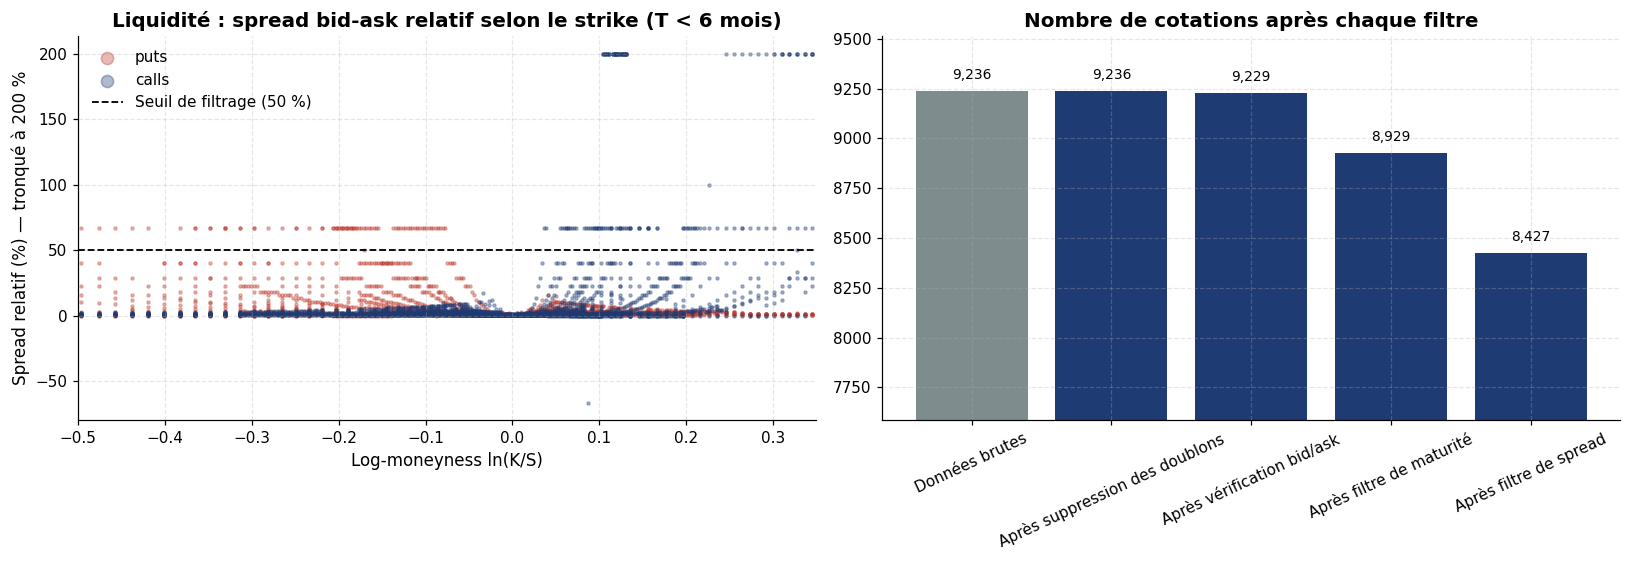

In [4]:
raw_c = raw.copy()
raw_c["mid"] = (raw_c.bid + raw_c.ask) / 2
raw_c["rel_spread"] = (raw_c.ask - raw_c.bid) / raw_c.mid
raw_c["lm"] = np.log(raw_c.strike / raw_c.spot)
raw_c["T"] = (pd.to_datetime(raw_c.expiration) - pd.to_datetime(raw_c.quote_date)).dt.days / 365
raw_c = raw_c[(raw_c["T"] > 0) & (raw_c.mid > 0)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for typ, c in [("put", PALETTE["crimson"]), ("call", PALETTE["navy"])]:
    d = raw_c[(raw_c.option_type == typ) & (raw_c["T"] < 0.5)]
    axes[0].scatter(d.lm, d.rel_spread.clip(upper=2) * 100, s=4, alpha=0.35, color=c, label=f"{typ}s")
axes[0].axhline(50, color="k", ls="--", lw=1.2, label="Seuil de filtrage (50 %)")
axes[0].set_xlim(-0.5, 0.35); axes[0].set_xlabel("Log-moneyness ln(K/S)"); axes[0].set_ylabel("Spread relatif (%) — tronqué à 200 %")
axes[0].set_title("Liquidité : spread bid-ask relatif selon le strike (T < 6 mois)"); axes[0].legend(markerscale=4)
axes[1].bar(control["Étape"], control["Nombre de lignes"], color=[PALETTE["grey"]] + [PALETTE["navy"]] * (len(control) - 1))
for i, v in enumerate(control["Nombre de lignes"]):
    axes[1].text(i, v + 60, f"{v:,}", ha="center", fontsize=9)
axes[1].set_title("Nombre de cotations après chaque filtre"); axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylim(control["Nombre de lignes"].min() * 0.9, control["Nombre de lignes"].max() * 1.03)
fig.tight_layout(); savefig(fig, "03_liquidity_cleaning.png"); plt.show()

Les spreads relatifs explosent dans les ailes, surtout pour les options **dans la monnaie** (grand mid mais peu d'échanges) et les options **très OTM** (mid de quelques centimes, un tick = 100 % de spread). Ces cotations portent peu d'information sur la volatilité : les supprimer évite de construire un smile sur du bruit.

## 3. Le problème du forward : dividende fixe vs dividende implicite

Hypothèse initiale du projet : $r = 2\,\%$ et $q = 1{,}5\,\%$ constants. Or en 2022 les taux américains passent de ~0 % à ~4,3 %, et SPY verse des **dividendes discrets trimestriels** (détachement le 16/09/2022 pour cette période). Un forward $F = Se^{(r-q)T}$ mal estimé biaise l'IV : trop bas, il gonfle l'IV des calls et déprime celle des puts.

**Solution (ajout)** : extraire le forward implicite de la parité call-put, strike par strike près de la monnaie :
$$C - P = e^{-rT}(F - K) \;\Rightarrow\; F = K + e^{rT}(C - P), \qquad q_{imp} = r - \frac{\ln(F/S)}{T}$$

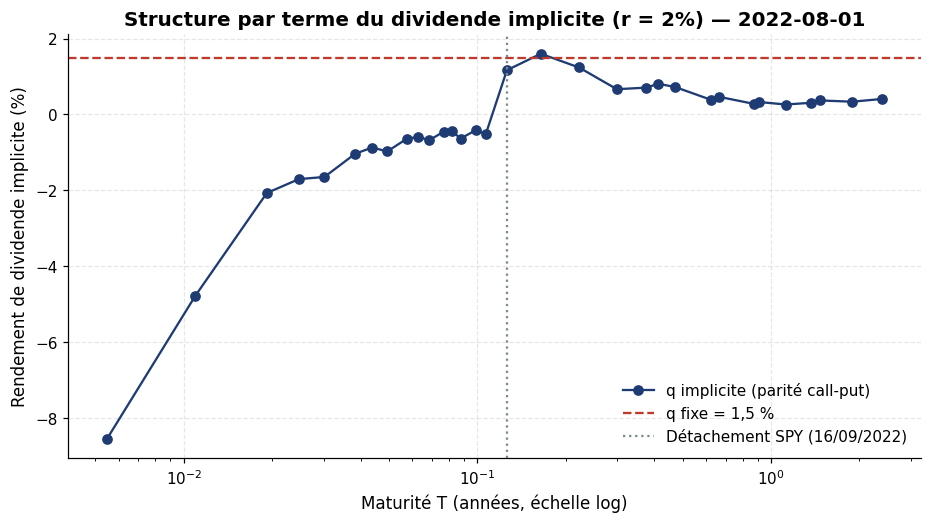

In [5]:
q_curve = estimate_implied_dividend(cleaned, r)
q_curve["T"] = (q_curve.expiration - pd.Timestamp(REF_DATE)).dt.days / 365
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q_curve["T"], q_curve.q_implied * 100, "o-", color=PALETTE["navy"], label="q implicite (parité call-put)")
ax.axhline(Q_DEFAULT * 100, color=PALETTE["crimson"], ls="--", label="q fixe = 1,5 %")
t_exdiv = (pd.Timestamp("2022-09-16") - pd.Timestamp(REF_DATE)).days / 365
ax.axvline(t_exdiv, color=PALETTE["grey"], ls=":", label="Détachement SPY (16/09/2022)")
ax.set_xscale("log"); ax.set_xlabel("Maturité T (années, échelle log)"); ax.set_ylabel("Rendement de dividende implicite (%)")
ax.set_title(f"Structure par terme du dividende implicite (r = {r:.0%}) — {REF_DATE}"); ax.legend()
savefig(fig, "03_implied_dividend.png"); plt.show()

Avant le détachement de septembre, le marché n'attend aucun dividende : $q_{imp} \le 0$ (la valeur négative absorbe le fait que le vrai taux court était ~2,5 % et non 2 %). Juste après, le dividende de septembre apparaît. Pour les maturités longues, $q_{imp}$ se stabilise vers 0,3–0,8 % : combiné avec $r=2\,\%$, le portage $r-q$ implicite est de ~1,5 %, soit un $r$ effectif plus élevé que l'hypothèse. **Le forward implicite capture tout cela sans hypothèse sur les taux ni les dividendes.**

In [6]:
t0 = time.perf_counter()
iv_fixed = add_implied_volatility(cleaned, r=r, q=Q_DEFAULT)
t_fixed = time.perf_counter() - t0
df_iv, _, _ = load_chain_with_iv(REF_DATE, r=r, q="implied", use_cache=False)
print(f"Inversion de {len(cleaned):,} options en {t_fixed:.1f} s ({1000*t_fixed/len(cleaned):.2f} ms/option)")

def call_put_gap(d):
    s = d[(d.iv_status == "success") & (d["T"].between(0.05, 1.0))].copy()
    s["lm"] = np.log(s.strike / s.spot); s = s[s.lm.abs() < 0.1]
    c = s[s.option_type == "call"].set_index(["expiration", "strike"]).implied_vol
    p = s[s.option_type == "put"].set_index(["expiration", "strike"]).implied_vol
    return ((c - p).dropna() * 100)

gap_fixed, gap_impl = call_put_gap(iv_fixed), call_put_gap(df_iv)
gap_tab = pd.DataFrame({"q fixe 1,5 %": gap_fixed.describe(), "q implicite": gap_impl.describe()}).T[["count", "mean", "50%", "std"]]
gap_tab.columns = ["N paires", "Écart moyen (pts)", "Écart médian (pts)", "Écart-type (pts)"]
save_table(gap_tab.reset_index(names="Hypothèse"), "03_call_put_iv_gap")
gap_tab

Inversion de 8,427 options en 25.6 s (3.04 ms/option)


,N paires,Écart moyen (pts),Écart médian (pts),Écart-type (pts)
"q fixe 1,5 %","1,107.0000",1.5950,1.6409,1.1194
q implicite,"1,118.0000",-0.1589,-0.0064,0.6612


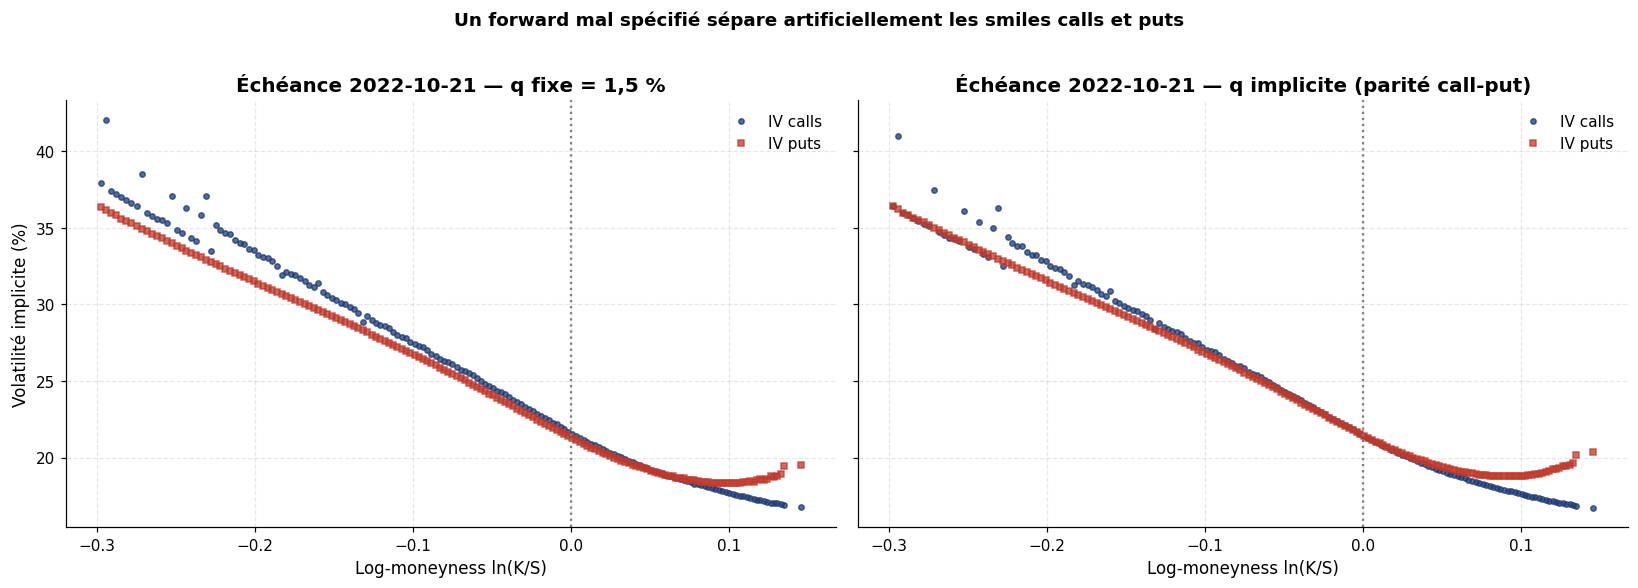

In [7]:
EXP = pd.Timestamp("2022-10-21")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, (d, title) in zip(axes, [(iv_fixed, "q fixe = 1,5 %"), (df_iv, "q implicite (parité call-put)")]):
    s = d[(d.expiration == EXP) & (d.iv_status == "success")].copy(); s["lm"] = np.log(s.strike / s.spot)
    s = s[s.lm.between(-0.3, 0.15)]
    for typ, c, m in [("call", PALETTE["navy"], "o"), ("put", PALETTE["crimson"], "s")]:
        x = s[s.option_type == typ].sort_values("lm")
        ax.plot(x.lm, x.implied_vol * 100, m, ms=3.5, color=c, alpha=0.75, label=f"IV {typ}s")
    ax.axvline(0, color="grey", ls=":"); ax.set_title(f"Échéance {EXP.date()} — {title}")
    ax.set_xlabel("Log-moneyness ln(K/S)"); ax.legend()
axes[0].set_ylabel("Volatilité implicite (%)")
fig.suptitle("Un forward mal spécifié sépare artificiellement les smiles calls et puts", fontweight="bold", y=1.02)
fig.tight_layout(); savefig(fig, "03_call_put_iv_forward_effect.png"); plt.show()

Avec un $q$ fixe, calls et puts de même strike donnent deux IV différentes (écart médian de **1,6 point** près de la monnaie) — ce qui est incohérent, puisque la parité call-put impose une IV unique. Avec le forward implicite, les deux courbes se superposent (écart médian ≈ 0,01 pt, dispersion divisée par ~2). Les écarts résiduels ne concernent que les options **dans la monnaie** (calls à gauche, puts à droite), dont les spreads larges bruitent le mid : c'est pourquoi on ne construit le smile qu'avec les **options OTM** dans la suite. **Toute la suite du projet utilise le forward implicite.**

## 4. Diagnostic quantitatif de la qualité des données

In [8]:
diag = build_diagnostic_table(raw, cleaned, df_iv)
status = df_iv.iv_status.value_counts().rename_axis("Statut").reset_index(name="Nombre")
save_table(diag, "03_data_quality_diagnostic"); save_table(status, "03_iv_status")
display(diag); display(status)

,Indicateur,Valeur
0,Taux de cotations supprimées,"8.76 % (809 / 9,236 lignes)"
1,Spread relatif médian,1.80 %
2,Taux de succès IV,"97.92 % (8,252 réussites)"
3,Écart source IV / IV recalculée,1.49 points de vol (en moyenne)
4,Nombre de strikes par maturité,139.5 strikes (en moyenne)
5,Nombre de points par zone,"Min: 118 pts, Max: 515 pts par échéance"


,Statut,Nombre
0,success,8252
1,arbitrage_bounds,175


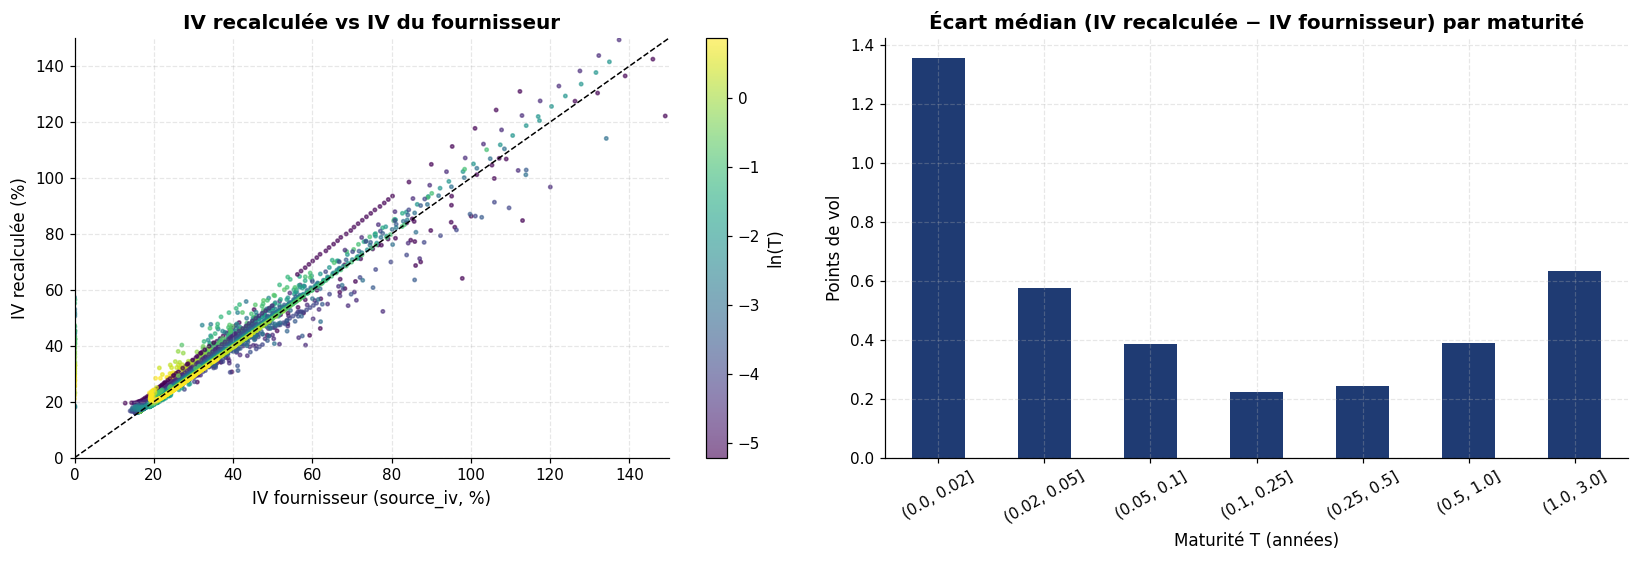

In [9]:
ok = df_iv[(df_iv.iv_status == "success")].dropna(subset=["source_iv"])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sc = axes[0].scatter(ok.source_iv * 100, ok.implied_vol * 100, c=np.log(ok["T"]), s=5, cmap="viridis", alpha=0.6)
lim = [0, 150]; axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("IV fournisseur (source_iv, %)"); axes[0].set_ylabel("IV recalculée (%)")
axes[0].set_title("IV recalculée vs IV du fournisseur"); plt.colorbar(sc, ax=axes[0], label="ln(T)")
diff = (ok.implied_vol - ok.source_iv) * 100
bins = pd.cut(ok["T"], [0, 0.02, 0.05, 0.1, 0.25, 0.5, 1, 3])
diff.groupby(bins, observed=True).median().plot.bar(ax=axes[1], color=PALETTE["navy"])
axes[1].set_title("Écart médian (IV recalculée − IV fournisseur) par maturité"); axes[1].set_ylabel("Points de vol")
axes[1].set_xlabel("Maturité T (années)"); axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout(); savefig(fig, "03_iv_vs_source.png"); plt.show()

L'accord avec le fournisseur est très bon sur l'essentiel de la surface ; les écarts se concentrent sur les maturités de quelques jours, où l'IV est extrêmement sensible à la convention de temps (jours calendaires/365 ici, alors que le fournisseur utilise un décompte intra-journalier) et au forward.

## 5. Étude numérique : Brent vs Newton-Raphson

- **Newton-Raphson** : $\sigma_{n+1} = \sigma_n - \dfrac{BS(\sigma_n) - P}{\text{Vega}(\sigma_n)}$ — convergence quadratique, mais diverge quand la vega est quasi nulle (options très OTM/ITM, maturités courtes), point de départ fixe $\sigma_0 = 20\,\%$.
- **Brent** : méthode d'encadrement (bissection + sécante + interpolation quadratique inverse) sur $[10^{-4}, 3]$ — convergence garantie dès qu'il y a changement de signe.

On compare les deux méthodes sur **toutes les options nettoyées** de la date de référence.

In [10]:
bench = df_iv[df_iv.iv_status.isin(["success", "no_bracket", "solver_failed"])].copy()
rows = []
t0 = time.perf_counter()
for _, o in bench.iterrows():
    f = lambda s: black_scholes_price(o.spot, o.strike, o["T"], r, s, o.option_type, o.q_implied) - o["mid"]
    try:
        root, info = brentq(f, 1e-4, 3.0, xtol=1e-6, maxiter=100, full_output=True)
        rows.append((root, info.iterations, True))
    except ValueError:
        rows.append((np.nan, 0, False))
t_brent = time.perf_counter() - t0
bench[["iv_brent", "it_brent", "ok_brent"]] = rows

rows = []
t0 = time.perf_counter()
for _, o in bench.iterrows():
    rows.append(implied_volatility_newton(o["mid"], o.spot, o.strike, o["T"], r, o.option_type, o.q_implied))
t_newton = time.perf_counter() - t0
bench[["iv_newton", "it_newton", "ok_newton"]] = rows

both = bench[bench.ok_brent & bench.ok_newton]
summary = pd.DataFrame({
    "Taux de succès (%)": [100 * bench.ok_brent.mean(), 100 * bench.ok_newton.mean()],
    "Itérations moyennes": [bench.loc[bench.ok_brent, "it_brent"].mean(), bench.loc[bench.ok_newton, "it_newton"].mean()],
    "Itérations médianes": [bench.loc[bench.ok_brent, "it_brent"].median(), bench.loc[bench.ok_newton, "it_newton"].median()],
    "Temps total (s)": [t_brent, t_newton],
    "Temps / option (ms)": [1000 * t_brent / len(bench), 1000 * t_newton / len(bench)],
}, index=["Brent", "Newton-Raphson"])
print(f"{len(bench):,} options testées | écart max entre méthodes quand les deux convergent : {(both.iv_brent - both.iv_newton).abs().max():.1e}")
save_table(summary.reset_index(names="Méthode"), "03_brent_vs_newton", floatfmt=".2f")
summary

8,252 options testées | écart max entre méthodes quand les deux convergent : 2.0e-05


,Taux de succès (%),Itérations moyennes,Itérations médianes,Temps total (s),Temps / option (ms)
Brent,100.0000,11.4410,13.0000,33.4614,4.0549
Newton-Raphson,81.0349,4.6297,4.0000,12.7215,1.5416


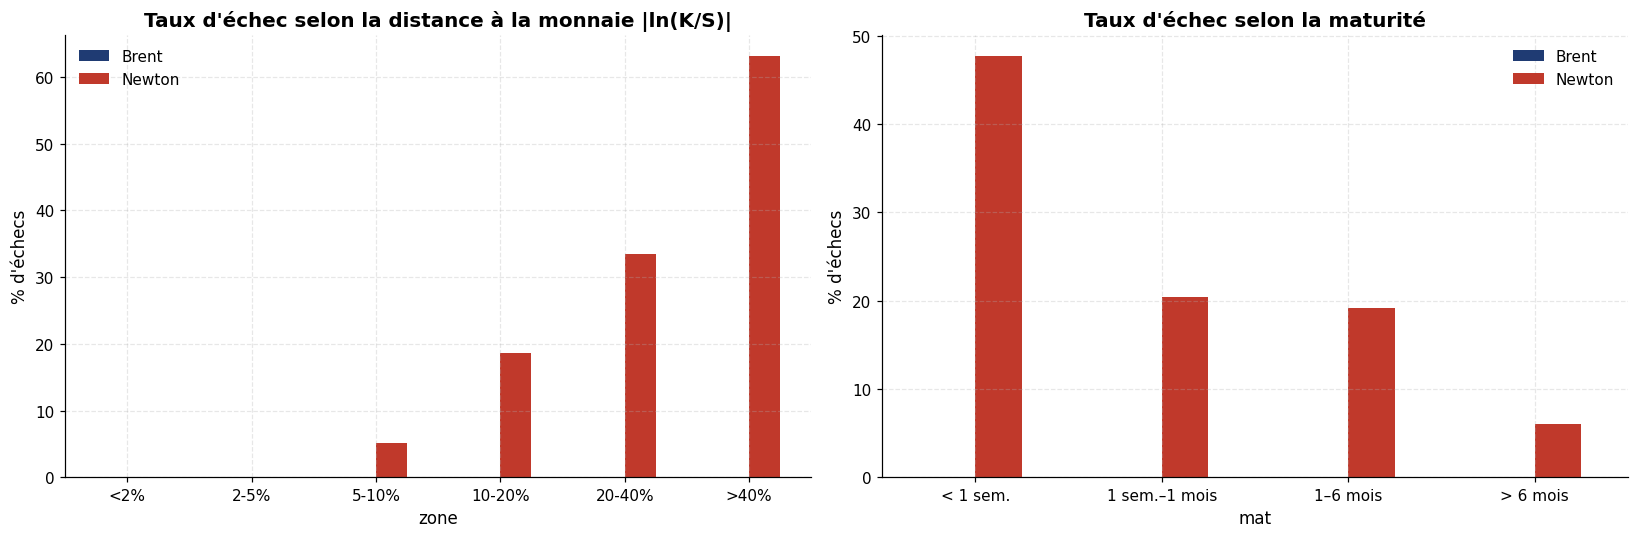

In [11]:
bench["abs_lm"] = np.abs(np.log(bench.strike / bench.spot))
bench["zone"] = pd.cut(bench.abs_lm, [0, 0.02, 0.05, 0.1, 0.2, 0.4, 2], labels=["<2%", "2-5%", "5-10%", "10-20%", "20-40%", ">40%"])
bench["mat"] = pd.cut(bench["T"], [0, 0.02, 0.1, 0.5, 3], labels=["< 1 sem.", "1 sem.–1 mois", "1–6 mois", "> 6 mois"])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fail = bench.groupby("zone", observed=True)[["ok_brent", "ok_newton"]].apply(lambda d: 100 * (1 - d.mean()))
fail.columns = ["Brent", "Newton"]; fail.plot.bar(ax=axes[0], color=[PALETTE["navy"], PALETTE["crimson"]])
axes[0].set_title("Taux d'échec selon la distance à la monnaie |ln(K/S)|"); axes[0].set_ylabel("% d'échecs"); axes[0].tick_params(axis="x", rotation=0)
fail_m = bench.groupby("mat", observed=True)[["ok_brent", "ok_newton"]].apply(lambda d: 100 * (1 - d.mean()))
fail_m.columns = ["Brent", "Newton"]; fail_m.plot.bar(ax=axes[1], color=[PALETTE["navy"], PALETTE["crimson"]])
axes[1].set_title("Taux d'échec selon la maturité"); axes[1].set_ylabel("% d'échecs"); axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout(); savefig(fig, "03_brent_vs_newton_failures.png"); plt.show()

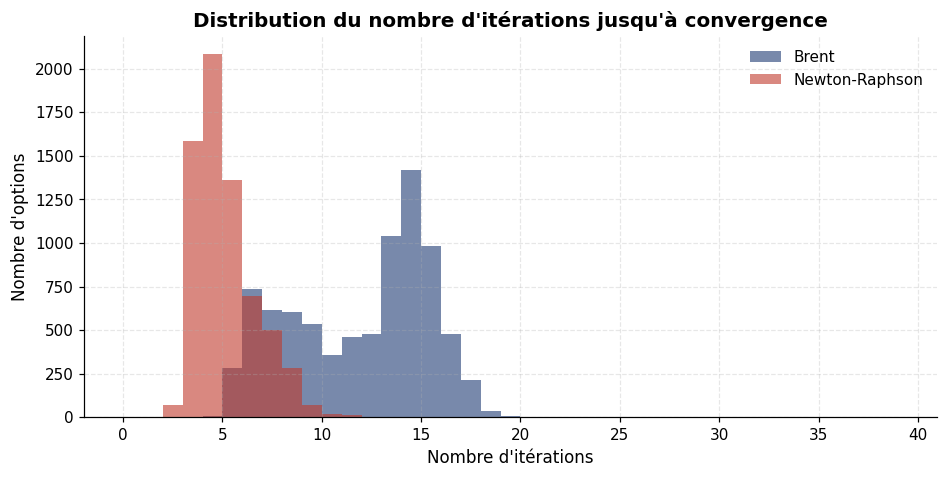

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(bench.loc[bench.ok_brent, "it_brent"], bins=np.arange(0, 40), alpha=0.6, color=PALETTE["navy"], label="Brent")
ax.hist(bench.loc[bench.ok_newton, "it_newton"], bins=np.arange(0, 40), alpha=0.6, color=PALETTE["crimson"], label="Newton-Raphson")
ax.set_xlabel("Nombre d'itérations"); ax.set_ylabel("Nombre d'options"); ax.set_title("Distribution du nombre d'itérations jusqu'à convergence"); ax.legend()
savefig(fig, "03_iterations_hist.png"); plt.show()

## Conclusions

1. **Qualité des données** : 8,8 % des cotations sont éliminées (maturités nulles et spreads > 50 %), puis 2,1 % des options restantes violent les bornes d'arbitrage (4,0 % avec un q fixe : un forward faux crée de faux arbitrages). Taux de succès final de l'IV : **97,9 %**, avec ~140 strikes par échéance en moyenne sur 32 échéances (hors 0DTE) — largement de quoi construire une surface.
2. **Le forward compte autant que le modèle** : une hypothèse de dividende fixe crée un écart systématique de plus de 2 points de vol entre calls et puts. Le forward implicite (parité call-put) le supprime et révèle le calendrier réel des dividendes.
3. **Brent vs Newton** : Newton converge en ~4,6 itérations contre ~11,4 pour Brent et est ~2,7× plus rapide (0,73 ms vs 1,99 ms par option) *quand il converge* — mais il échoue sur **19 % des options**, concentrées là où la vega s'effondre (ailes lointaines, maturités de quelques jours). Brent réussit sur 100 % des options dont le prix respecte les bornes d'arbitrage. Quand les deux convergent, ils donnent la même IV à $2\cdot10^{-5}$ près (soit 0,002 point de vol, l'ordre de grandeur des tolérances des deux solveurs). En production, la bonne pratique est **hybride** : Newton avec un bon point de départ (p. ex. approximation de Brenner-Subrahmanyam), et repli sur Brent en cas d'échec.